# Gradient Boosting

## What Is Gradient Boosting?

Gradient Boosting is a **sequential ensemble method** where each new model is trained to correct the errors made by all previous models combined. Unlike AdaBoost, which corrects errors by reweighting samples, Gradient Boosting corrects errors by directly **fitting the negative gradient of the loss function**.

The final model is an additive combination of many weak learners:

$$F(\mathbf{x}) = f_1(\mathbf{x}) + f_2(\mathbf{x}) + f_3(\mathbf{x}) + \cdots$$

Each $f_m$ is a small tree that contributes a correction to the running prediction.

## Why Do We Need Gradient Boosting?

AdaBoost works well in many cases, but it has meaningful limitations:

- It is sensitive to noise and outliers (which accumulate large weights)
- It is tied to exponential loss, making it inflexible
- It works best only with classification and simple decision stumps

Gradient Boosting generalizes the boosting idea by framing it as **numerical optimization in function space**. This means:

- It can optimize **any differentiable loss function** — MSE for regression, log-loss for classification, and custom losses for specialized tasks
- It works equally well for both regression and classification
- It is considerably more flexible and powerful than AdaBoost

## The Core Idea: Fitting Residuals

The key intuition is simple. Suppose your current model $F(\mathbf{x})$ predicts a value, and the true value is $y$. The error is:

$$r = y - F(\mathbf{x})$$

Instead of tweaking the existing model, you train a **new small tree** $h_m(\mathbf{x})$ to predict this residual error. You then add it to the current model:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + h_m(\mathbf{x})$$

The new model is now slightly better. Repeat this process — compute the new residuals, fit another tree, add it in — and the ensemble gradually improves.

Each tree is not predicting $y$ directly. It is predicting **how wrong the current ensemble is**, and adding a correction.

## Mathematical Derivation (Regression Case)

For regression with MSE loss:

$$\mathcal{L} = \frac{1}{2}(y - F(\mathbf{x}))^2$$

Take the gradient of the loss with respect to the current prediction $F(\mathbf{x})$:

$$\frac{\partial \mathcal{L}}{\partial F(\mathbf{x})} = -(y - F(\mathbf{x}))$$

The **negative gradient** is therefore:

$$r = y - F(\mathbf{x})$$

This is exactly the residual. So for MSE loss, fitting the residuals and fitting the negative gradient are the same thing. For other loss functions, the negative gradient gives a generalized version of "residuals" — this is why Gradient Boosting works for any differentiable loss.

At each iteration $m$, a new weak learner $h_m(\mathbf{x})$ is fit to these pseudo-residuals, and the model is updated with a **learning rate** $\eta$ that controls the step size:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

A smaller $\eta$ means each tree contributes less, requiring more trees but generally giving better generalization.

## Gradient Boosting for Classification (Binary Case)

In regression, the negative gradient of MSE loss is simply the residual $y - F(\mathbf{x})$. In classification, the story is slightly different — we work with **probabilities and log-odds** instead of raw predictions.

### Setup

The model outputs a raw score $F(\mathbf{x})$, called the **log-odds**. This is converted to a probability using the sigmoid:

$$p(\mathbf{x}) = \sigma(F(\mathbf{x})) = \frac{1}{1 + e^{-F(\mathbf{x})}}$$

### Loss Function

We minimize **Binary Cross-Entropy**:

$$\mathcal{L} = -\left[y\log(p) + (1-y)\log(1-p)\right]$$

### The Pseudo-Residual

Taking the gradient of $\mathcal{L}$ with respect to $F(\mathbf{x})$ via the chain rule gives a clean result:

$$\frac{\partial \mathcal{L}}{\partial F(\mathbf{x})} = p - y$$

So the **negative gradient** — what the next tree is trained on — is:

$$r = y - p(\mathbf{x})$$

This is the **pseudo-residual**. Compare the two cases side by side:

| Task | Pseudo-Residual |
|---|---|
| Regression | $r = y - F(\mathbf{x})$ |
| Classification | $r = y - p(\mathbf{x})$ |

The only difference is that in classification, we subtract the **predicted probability** rather than the raw score. Intuitively, if the true label is 1 and the model predicts $p = 0.2$, the residual is $0.8$ — a large correction is needed. If the model already predicts $p = 0.95$, the residual is only $0.05$ — a small nudge suffices.

### Full Algorithm

**Initialize** with the log-odds of the training set:

$$F_0(\mathbf{x}) = \log\frac{\bar{y}}{1 - \bar{y}}$$

**For each iteration** $m = 1, 2, \ldots, T$:

1. Compute predicted probabilities: $\quad p_i = \sigma(F_{m-1}(\mathbf{x}_i))$

2. Compute pseudo-residuals: $\quad r_i = y_i - p_i$

3. Fit a shallow tree $h_m(\mathbf{x})$ to $\{r_i\}$

4. Update the model: $\quad F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$

**Final prediction** — apply a threshold to the converged probability:

$$\hat{y} = \begin{cases} 1 & \text{if } \sigma(F(\mathbf{x})) > 0.5 \\ 0 & \text{otherwise} \end{cases}$$

Because binary cross-entropy is a **convex loss**, gradient descent over it has no local minima — the algorithm is guaranteed to converge to the global minimum, making the process stable.

## Gradient Boosting as Functional Gradient Descent

This is the deep insight behind Gradient Boosting.

In ordinary gradient descent, we optimize a loss over **parameters** $\theta$:

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}$$

In Gradient Boosting, we optimize a loss over **functions** $F(\mathbf{x})$:

$$F_m(\mathbf{x}) \leftarrow F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

Each new tree $h_m$ is a **step in function space** — a small correction that moves the prediction in the direction that reduces the loss most. The algorithm is literally doing gradient descent, but instead of updating numbers, it is updating a function by adding small trees to it. This is why the method is so general and powerful.

## How It Differs from AdaBoost

| Property | AdaBoost | Gradient Boosting |
|---|---|---|
| Error correction mechanism | Reweights misclassified samples | Fits residuals (negative gradients) |
| Loss function | Fixed (exponential loss) | Any differentiable loss |
| Task support | Primarily classification | Regression and classification |
| Sensitivity to noise | High | Lower (depends on loss choice) |
| Weak learner | Decision stumps (depth = 1) | Shallow trees (typically depth 3–8) |
| Theoretical framing | Weighted voting | Functional gradient descent |

The fundamental shift is that AdaBoost manipulates the **data** (through reweighting) to force the next learner to focus on mistakes, while Gradient Boosting manipulates the **target** (through residuals) to directly tell the next learner what to fix.

## Key Hyperparameters

### Number of Trees — `n_estimators`

The total number of sequential trees to build. More trees increase model complexity and can improve accuracy, but also increase the risk of overfitting and slow down training. Unlike Random Forest, adding more trees in Gradient Boosting does not always help — it can overfit.

### Learning Rate — $\eta$ (`learning_rate`)

Controls how much each tree contributes to the final model:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

A smaller $\eta$ means each tree takes a smaller step, requiring more trees to reach a good solution but typically generalizing better. The golden rule is:

$$\text{Small } \eta + \text{Large } n\_estimators \implies \text{Strong model}$$

### Tree Depth — `max_depth`

Controls the complexity of each individual tree. Gradient Boosting typically uses shallow trees (depth 3–8), unlike Random Forest which uses deep trees. Shallow trees are weak learners with high bias — the boosting process reduces this bias iteratively.

## When To Use Gradient Boosting

**Use Gradient Boosting when:**

- Working with structured or tabular data
- You want maximum predictive accuracy without deep learning
- The loss function needs to be customized for the problem
- Feature interactions and non-linearities are present in the data

**Avoid Gradient Boosting when:**

- The dataset is extremely large — sequential training does not scale as easily as parallel methods
- Real-time low-latency inference is required — a forest of hundreds of trees adds prediction overhead
- Data is primarily images, audio, or text sequences — deep learning is more appropriate

## Modern Variants

The standard sklearn implementation of Gradient Boosting is powerful but relatively slow on large datasets. Three optimized variants have become the dominant tools for tabular ML in both industry and competitions:

| Library | Key Innovation |
|---|---|
| **XGBoost** | Regularized boosting, hardware optimization, handles missing values natively |
| **LightGBM** | Leaf-wise tree growth, histogram-based splitting — extremely fast on large data |
| **CatBoost** | Native handling of categorical features, symmetric trees, less tuning required |

All three follow the same Gradient Boosting framework described here. Understanding the fundamentals above means you already understand the core of all three.

Text(0.5, 1.0, 'Synthetic Dataset')

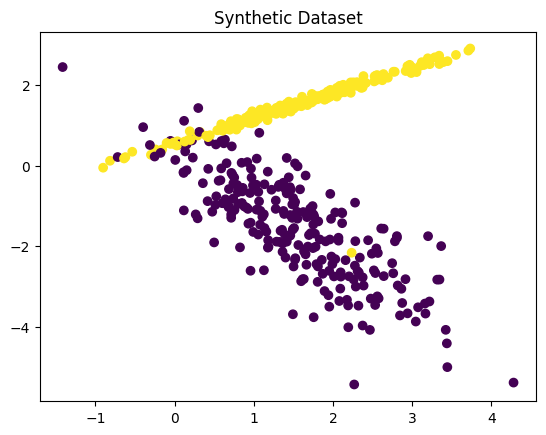

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# ----------------------------
# 1. Generate Dataset
# ----------------------------
np.random.seed(42)

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

plt.scatter(X[:,0], X[:, 1], c=y)
plt.title("Synthetic Dataset")

In [2]:
# ----------------------------
# 2. Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ----------------------------
# 3. Model
# ----------------------------
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [3]:
# ----------------------------
# 4. Predictions
# ----------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ----------------------------
# 5. Metrics
# ----------------------------
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.93
ROC-AUC: 0.9935974389755903
Confusion Matrix:
 [[48  3]
 [ 4 45]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        51
           1       0.94      0.92      0.93        49

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



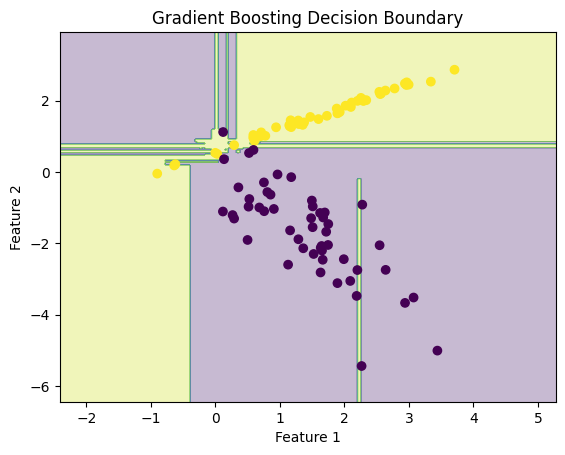

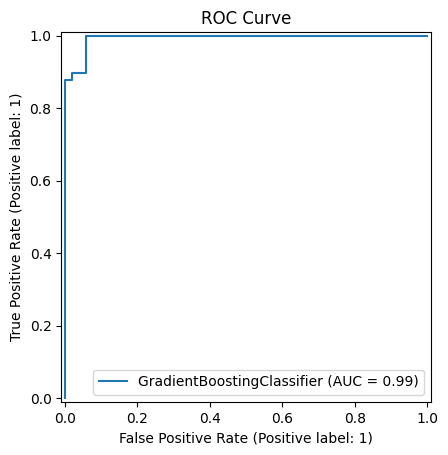

In [4]:
# ----------------------------
# 6. Decision Boundary Plot
# ----------------------------
# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.title("Gradient Boosting Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ----------------------------
# 7. ROC Curve
# ----------------------------
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()